In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [7]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

categorical_columns = list(df.dtypes[df.dtypes== 'str'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(" ", "_")

In [8]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu,9305-cdskc,1452-kiovk,6713-okomc,7892-pookp,6388-tabgu
gender,female,male,male,male,female,female,male,female,female,male
seniorcitizen,0,0,0,0,0,0,0,0,0,0
partner,yes,no,no,no,no,no,no,no,yes,no
dependents,no,no,no,no,no,no,yes,no,no,yes
tenure,1,34,2,45,2,8,22,10,28,62
phoneservice,no,yes,yes,no,yes,yes,yes,no,yes,yes
multiplelines,no_phone_service,no,no,no_phone_service,no,yes,yes,no_phone_service,yes,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic,fiber_optic,fiber_optic,dsl,fiber_optic,dsl
onlinesecurity,no,yes,yes,yes,no,no,no,yes,no,yes


In [18]:
tc = pd.to_numeric(df.totalcharges, errors='coerce')

In [19]:
df['totalcharges'] = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

In [22]:
(df.churn == 'yes').astype(int).head()

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

In [23]:
df.churn = (df.churn == 'yes').astype(int)

In [25]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-vhveg,female,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,29.85,29.85,0
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one_year,no,mailed_check,56.95,1889.50,0
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed_check,53.85,108.15,1
3,7795-cfocw,male,0,no,no,45,no,no_phone_service,dsl,yes,...,yes,yes,no,no,one_year,no,bank_transfer_(automatic),42.30,1840.75,0
4,9237-hqitu,female,0,no,no,2,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.70,151.65,1


## 3.3 Setting up the validation framework

In [38]:
from sklearn.model_selection import train_test_split

df_train_val, df_test = train_test_split(df, test_size=0.2, random_state=1, shuffle=True)

In [39]:
df_train, df_val = train_test_split(df_train_val,test_size=0.25, random_state=1, shuffle=True)


In [40]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [41]:
df_train.reset_index(drop=True,inplace=True)
df_val.reset_index(drop=True,inplace=True)
df_test.reset_index(drop=True,inplace=True)

In [42]:
y_train = df_train['churn'].values
del df_train['churn']

y_val = df_val['churn'].values
del df_val['churn']

y_test = df_test['churn'].values
del df_test['churn']

## 3.04 Exploratory Data Analysis

In [46]:
df_train_val.reset_index(drop=True, inplace=True)

In [53]:
df_train_val.churn.value_counts(normalize=True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [56]:
global_churn_rate = df_train_val.churn.mean()
round(global_churn_rate, 2)

np.float64(0.27)

In [58]:
numerical = ["tenure", "monthlycharges", "totalcharges"]

In [59]:
df_train_val.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [61]:
categorical = [
    'gender', 'seniorcitizen', 'partner', 'dependents',
    'phoneservice', 'multiplelines', 'internetservice',
    'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
    'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
    'paymentmethod',
    ]

In [62]:
df_train_val[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

## 3.05 Feature Importance: Churn Rate and Risk Ratio

In [66]:
churn_female = df_train_val[df_train_val.gender=='female'].churn.mean()
churn_male = df_train_val[df_train_val.gender=='male'].churn.mean()

In [67]:
churn_female, churn_male, global_churn_rate

(np.float64(0.27682403433476394),
 np.float64(0.2632135306553911),
 np.float64(0.26996805111821087))

In [68]:
df_train_val.partner.value_counts()

partner
no     2932
yes    2702
Name: count, dtype: int64

In [69]:
churn_partner = df_train_val[df_train_val.partner == 'yes'].churn.mean()
churn_no_partner = df_train_val[df_train_val.partner == 'no'].churn.mean()

In [70]:
print(churn_partner)
print(churn_no_partner)
print(churn_partner-churn_no_partner)

0.20503330866025166
0.3298090040927694
-0.12477569543251776


In [78]:
df_train_val.groupby("gender")['churn'].mean()

gender
female    0.276824
male      0.263214
Name: churn, dtype: float64

In [ ]:
from IPython.display import display

In [87]:
for c in categorical:
    df_group = df_train_val.groupby(c)['churn'].agg(['mean','count'])
    df_group['diff'] = df_group['mean'] - global_churn_rate
    df_group['risk'] = df_group['mean'] / global_churn_rate
    print(c)
    display(df_group)
    print()

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980



seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208



partner


...

,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730



paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560



paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


## 3.06 Feature importance: Mutual information

In [96]:
from sklearn.metrics import mutual_info_score

In [97]:
mutual_info_score(df_train_val.churn, df_train_val.contract)

0.0983203874041556

In [98]:
mutual_info_score(df_train_val.churn, df_train_val.gender)

0.0001174846211139946

In [100]:
mutual_info_score(df_train_val.partner, df_train_val.churn)

0.009967689095399745

In [101]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_train_val.churn)

In [105]:

mi = df_train_val[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

## 3.07 Feature importance: Correlation

In [106]:
df_train_val[numerical].corrwith(df_train_val.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [107]:
df_train_val[df_train_val.tenure <= 2].churn.mean()

np.float64(0.5953420669577875)

In [108]:
df_train_val[(df_train_val.tenure > 2) &
             (df_train_val.tenure < 6)].churn.mean()

np.float64(0.4701670644391408)

<Axes: xlabel='tenure', ylabel='mean'>

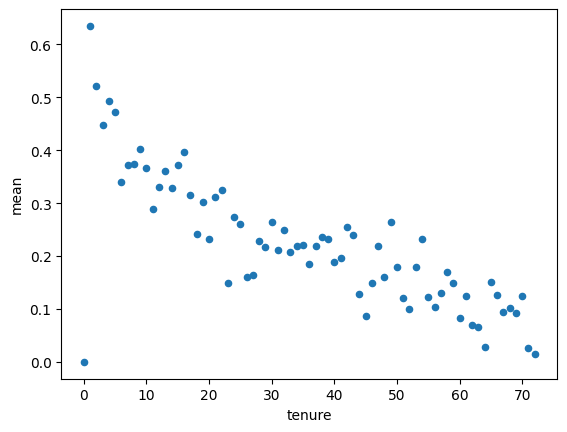

In [133]:
df_train_val.groupby("tenure")["churn"].agg(["mean","std"]).reset_index().plot(x='tenure',
                                                                         y='mean',
                                                                        kind='scatter')

## 3.08 One-hot encoding

In [134]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.preprocessing import OneHotEncoder

In [164]:
train_dicts = df_train[categorical+numerical].to_dict(orient='records')

{'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'yes',
 'deviceprotection': 'yes',
 'techsupport': 'yes',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'two_year',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 72,
 'monthlycharges': 115.5,
 'totalcharges': 8425.15}

In [ ]:
dv = DictVectorizer(sparse=False)

In [169]:
X_train = dv.fit_transform(train_dicts)
feat_names = dv.get_feature_names_out()

In [179]:
val_dicts = df_val[categorical+numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)
print(X_val.shape)

(1409, 45)


In [187]:
ohe = OneHotEncoder(sparse_output=False, drop='if_binary')
res = ohe.fit_transform(df_train[categorical])
col_names = ohe.get_feature_names_out()

In [201]:
onehot_encoded = pd.DataFrame(data=res, columns=col_names)

In [195]:
len(numerical)

3

## 3.09 Logistic regression

In [196]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

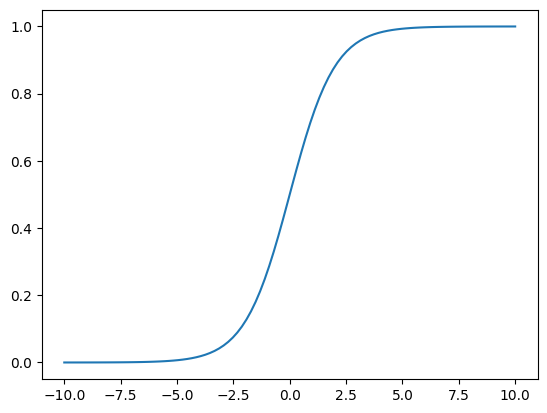

In [199]:
z = np.linspace(-10,10,100)
plt.plot(z, sigmoid(z))

In [200]:
def linear_regression(xi):
    result = w0

    for j in range(len(w)):
        result = result + xi[j]*w[j]
    
    return result

def logistic_regression(xi):
    score = linear_regression(xi)
    return sigmoid(score)

## 3.11 Training logistic regression with Scikit-Learn

In [202]:
from sklearn.linear_model import LogisticRegression

In [228]:
model = LogisticRegression(max_iter=10_000,)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [229]:
model.intercept_

array([-0.04544303])

In [230]:
model.coef_

array([[ 6.85794591e-01,  3.19920675e-02, -6.77671373e-01,
         5.52112555e-02, -1.50959701e-02,  1.13000743e-01,
        -1.59809380e-01,  8.69239221e-02,  3.92967182e-02,
         8.18567076e-04, -4.98484830e-01,  6.98409495e-01,
        -1.59809380e-01, -1.78794472e-02, -1.87685263e-01,
         6.84169022e-02,  1.59383646e-01,  1.16526126e-01,
        -1.59809380e-01,  8.33985394e-02,  2.84449572e-01,
        -1.59809380e-01, -8.45249071e-02, -1.61358559e-01,
         2.01473844e-01, -4.42520439e-02,  8.43673292e-02,
        -5.31534034e-02, -2.27967838e-03,  1.06546508e-01,
        -1.09981413e-02,  6.84169022e-02, -2.83016168e-02,
         1.95173241e-01, -9.47519249e-02, -1.59809380e-01,
         2.94676590e-01, -5.48797047e-02, -1.59809380e-01,
         2.54804370e-01,  2.34070139e-01, -1.59809380e-01,
        -3.41454737e-02, -6.84027258e-02,  3.94703163e-04]])

In [231]:
y_pred = model.predict_proba(X_train)[:,1]

In [232]:
y_pred = model.predict_proba(X_val)[:,1]

In [233]:
churn_decision = (y_pred >= 0.5)
df_val[churn_decision].customerid

3       8433-wxgna
8       3440-jpscl
12      7228-omtpn
19      6711-fldfb
24      2612-ranwt
           ...    
1397    5976-jcjrh
1398    2034-cgrhz
1399    5276-kqwhg
1407    6521-yytyi
1408    3049-solay
Name: customerid, Length: 315, dtype: str

In [234]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [235]:
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

In [236]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val

In [237]:
df_pred

,probability,prediction,actual
0,0.006666,0,0
1,0.204826,0,0
2,0.217704,0,0
3,0.563754,1,1
4,0.218419,0,0
...,...,...,...
1404,0.292814,0,0
1405,0.041084,0,1
1406,0.151560,0,0
1407,0.788704,1,1


In [238]:
df_pred['correct'] = df_pred.prediction == df_pred.actual

In [239]:
df_pred.correct.mean()

np.float64(0.8034066713981547)

## 3.11 Model interpretation

In [242]:
list(dv.get_feature_names_out())

['contract=month-to-month',
 'contract=one_year',
 'contract=two_year',
 'dependents=no',
 'dependents=yes',
 'deviceprotection=no',
 'deviceprotection=no_internet_service',
 'deviceprotection=yes',
 'gender=female',
 'gender=male',
 'internetservice=dsl',
 'internetservice=fiber_optic',
 'internetservice=no',
 'monthlycharges',
 'multiplelines=no',
 'multiplelines=no_phone_service',
 'multiplelines=yes',
 'onlinebackup=no',
 'onlinebackup=no_internet_service',
 'onlinebackup=yes',
 'onlinesecurity=no',
 'onlinesecurity=no_internet_service',
 'onlinesecurity=yes',
 'paperlessbilling=no',
 'paperlessbilling=yes',
 'partner=no',
 'partner=yes',
 'paymentmethod=bank_transfer_(automatic)',
 'paymentmethod=credit_card_(automatic)',
 'paymentmethod=electronic_check',
 'paymentmethod=mailed_check',
 'phoneservice=no',
 'phoneservice=yes',
 'seniorcitizen',
 'streamingmovies=no',
 'streamingmovies=no_internet_service',
 'streamingmovies=yes',
 'streamingtv=no',
 'streamingtv=no_internet_servic

In [244]:
model.coef_[0]

array([ 6.85794591e-01,  3.19920675e-02, -6.77671373e-01,  5.52112555e-02,
       -1.50959701e-02,  1.13000743e-01, -1.59809380e-01,  8.69239221e-02,
        3.92967182e-02,  8.18567076e-04, -4.98484830e-01,  6.98409495e-01,
       -1.59809380e-01, -1.78794472e-02, -1.87685263e-01,  6.84169022e-02,
        1.59383646e-01,  1.16526126e-01, -1.59809380e-01,  8.33985394e-02,
        2.84449572e-01, -1.59809380e-01, -8.45249071e-02, -1.61358559e-01,
        2.01473844e-01, -4.42520439e-02,  8.43673292e-02, -5.31534034e-02,
       -2.27967838e-03,  1.06546508e-01, -1.09981413e-02,  6.84169022e-02,
       -2.83016168e-02,  1.95173241e-01, -9.47519249e-02, -1.59809380e-01,
        2.94676590e-01, -5.48797047e-02, -1.59809380e-01,  2.54804370e-01,
        2.34070139e-01, -1.59809380e-01, -3.41454737e-02, -6.84027258e-02,
        3.94703163e-04])

In [254]:
coeffs = zip(list(dv.get_feature_names_out()), model.coef_[0].astype(float))

In [255]:
dict(coeffs)

{'contract=month-to-month': np.float64(0.6857945914839808),
 'contract=one_year': np.float64(0.03199206751803877),
 'contract=two_year': np.float64(-0.6776713731314662),
 'dependents=no': np.float64(0.055211255512773075),
 'dependents=yes': np.float64(-0.015095970117043807),
 'deviceprotection=no': np.float64(0.1130007429463804),
 'deviceprotection=no_internet_service': np.float64(-0.15980937987625318),
 'deviceprotection=yes': np.float64(0.08692392211646925),
 'gender=female': np.float64(0.039296718237065625),
 'gender=male': np.float64(0.0008185670761903932),
 'internetservice=dsl': np.float64(-0.498484829528635),
 'internetservice=fiber_optic': np.float64(0.6984094951256778),
 'internetservice=no': np.float64(-0.15980937987625318),
 'monthlycharges': np.float64(-0.017879447171919305),
 'multiplelines=no': np.float64(-0.18768526292503326),
 'multiplelines=no_phone_service': np.float64(0.0684169022316035),
 'multiplelines=yes': np.float64(0.15938364587006582),
 'onlinebackup=no': np.f

In [256]:
small = ['contract','tenure','monthlycharges']
df_train[small].iloc[:10].to_dict(orient='records')

[{'contract': 'two_year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 75.55},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 80.85},
 {'contract': 'two_year', 'tenure': 18, 'monthlycharges': 20.1},
 {'contract': 'month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 75.1},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 70.3},
 {'contract': 'two_year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'month-to-month', 'tenure': 6, 'monthlycharges': 109.9}]

In [258]:
dict_train_small = df_train[small].to_dict(orient='records')
dict_val_small = df_val[small].to_dict(orient='records')

In [259]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dict_train_small)
dv_small.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'monthlycharges', 'tenure'], dtype=object)

In [260]:
X_train_small = dv_small.transform(dict_train_small)

In [262]:
model = LogisticRegression()
model.fit(X_train_small, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [266]:
w0 = model.intercept_
w0

array([-2.4779576])

In [269]:
w = model.coef_[0]
w

array([ 0.9711394 , -0.02379507, -0.94828863,  0.02748534, -0.03619005])

In [273]:
dict(zip(dv_small.get_feature_names_out(), w.round(3)))

{'contract=month-to-month': np.float64(0.971),
 'contract=one_year': np.float64(-0.024),
 'contract=two_year': np.float64(-0.948),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}